# RF Calibration Example

## 1. Why Probabilities Can Be Misleading

Random Forests aggregate “yes/no” votes from many decision trees. The final probability is just the fraction of “yes” votes. That leads to two problems:

1. **Extreme clustering**  
   - Predictions jump in coarse 1 percent steps (0%, 1%, …, 100%).  
   - Even if the true likelihood is around 60–70%, you’ll often see 0%, 1%, 99% or 100%.

2. **Over‐confidence from correlation**  
   - Trees trained on similar patterns tend to agree—even when they’re wrong.  
   - Fully grown trees have zero training error, pushing votes toward the extremes.

These effects give a U-shaped distribution of raw RF probabilities, with too few values in the middle.

---

## 2. Six-Stage Pipeline (In Simple Terms)

1. **Generate data**  
   Create a synthetic binary‐classification dataset with `make_classification`.

2. **Split data**  
   Divide into:  
   - **Training set** for fitting the RF  
   - **Calibration set** for learning post-processing adjustments  
   - **Test set** for final evaluation

3. **Build pipeline**  
   Stack a `StandardScaler` (optional) and a `RandomForestClassifier`.

4. **Hyperparameter tuning**  
   Use `GridSearchCV` (e.g. on `n_estimators`, `max_depth`) to find the best RF settings.

5. **Calibrate probabilities**  
   Three methods:  
   - **Isotonic regression**: flexible, non-decreasing adjustment  
   - **Platt scaling** (sigmoid): simple S-shaped curve  
   - **Temperature scaling**: divide RF log-odds by a learned temperature T

6. **Evaluate & plot**  
   - **Brier score** and **ROC AUC**  
   - **Classification report** at 0.5 threshold  
   - **Calibration curves** comparing mean predicted vs. observed frequency

---

## 3. Calibration Methods in Detail

- **Isotonic**  
  Learns a stepwise recalibration function. Good when you have plenty of calibration data.

- **Sigmoid (Platt)**  
  Fits a logistic curve. Stable with smaller calibration sets.

- **Temperature scaling**  
  Works on RF’s log-odds:  
  \[p_t = σ\bigl(\tfrac{\log(p/(1-p))}{T}\bigr)\]  
  Finds the single scalar T that minimizes negative log‐likelihood on the calibration set.

---

## 4. Key Takeaways

- Raw RF probabilities tend to be over-confident and bunched at 0 or 1.  
- Post‐processing (isotonic, sigmoid or temperature) smooths and corrects those biases.  
- Always hold out a dedicated calibration set to avoid overfitting your adjustments.  
- Inspect both numeric metrics (Brier, ROC AUC) and calibration curves to be sure.


2025-06-25 11:54:48 INFO __main__: Stage 1: Generated data X=(10000, 20), y=(10000,), balance={0: 5003, 1: 4997}
2025-06-25 11:54:48 INFO __main__: Stage 2: Split data into train=(6000, 20), calib=(2000, 20), test=(2000, 20)
2025-06-25 11:54:48 INFO __main__: Stage 3: Pipeline constructed with steps: {'scaler': StandardScaler(), 'rf': RandomForestClassifier(n_jobs=-1, random_state=42)}
2025-06-25 11:55:00 INFO __main__: Stage 4: Best params: {'rf__max_depth': 20, 'rf__n_estimators': 200}
2025-06-25 11:55:00 INFO __main__: Stage 5: Calibration complete for isotonic
2025-06-25 11:55:00 INFO __main__: Stage 5: Calibration complete for sigmoid
2025-06-25 11:55:00 INFO __main__: Evaluating model: uncalibrated
2025-06-25 11:55:00 INFO __main__: uncalibrated Brier score: 0.0674
2025-06-25 11:55:00 INFO __main__: uncalibrated ROC AUC: 0.9775
2025-06-25 11:55:00 INFO __main__: uncalibrated Classification Report:
              precision    recall  f1-score   support

           0       0.93     

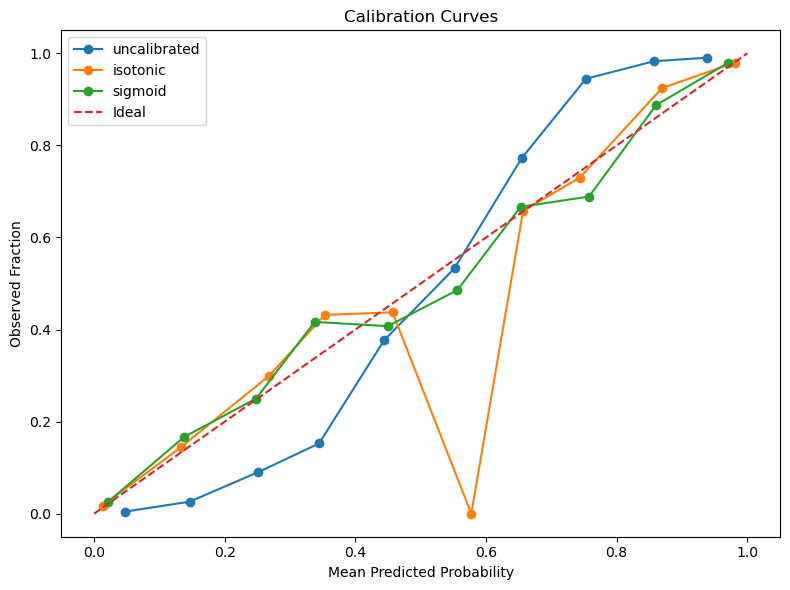

2025-06-25 11:55:01 INFO __main__: Stage 6: Evaluation and plotting complete


In [1]:
import argparse
import json
import logging
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
from scipy.optimize import minimize
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (brier_score_loss, classification_report,
                             roc_auc_score)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Configure root logger
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(name)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger(__name__)


@dataclass(frozen=True)
class DataSplit:
    X_train: np.ndarray
    X_calib: np.ndarray
    X_test: np.ndarray
    y_train: np.ndarray
    y_calib: np.ndarray
    y_test: np.ndarray


class PipelineConfig:
    """
    Configuration for the RF calibration pipeline.
    """
    def __init__(
        self,
        n_samples: int = 10000,
        n_features: int = 20,
        n_informative: int = 5,
        test_size: float = 0.2,
        calib_size: float = 0.2,
        random_state: int = 42,
        param_grid: Optional[Dict[str, List[Any]]] = None,
        calib_methods: Tuple[str, ...] = ("isotonic", "sigmoid"),
        n_bins: int = 10,
        plot_path: Optional[Path] = None,
        metrics: Tuple[str, ...] = ("brier", "roc_auc", "classification_report"),
        preprocessor: str = "standard"
    ):
        self.n_samples = n_samples
        self.n_features = n_features
        self.n_informative = n_informative
        self.test_size = test_size
        self.calib_size = calib_size
        self.random_state = random_state
        self.param_grid = param_grid or {
            "rf__n_estimators": [100, 200],
            "rf__max_depth": [None, 10, 20],
        }
        self.calib_methods = calib_methods
        self.n_bins = n_bins
        self.plot_path = plot_path
        self.metrics = metrics
        self.preprocessor = preprocessor
        
import argparse
import json
import logging
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
from scipy.optimize import minimize
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (brier_score_loss, classification_report,
                             roc_auc_score)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# … your logging setup, DataSplit, PipelineConfig, etc. …

class TemperatureCalibratedClassifier(BaseEstimator, ClassifierMixin):
    """
    Wrap a fitted classifier with temperature scaling calibration.
    After fitting on (X_calib, y_calib), predict_proba applies:
        σ( logits / T )
    where σ is the sigmoid and logits = log(p/(1-p)).
    """
    def __init__(self, base_estimator: Pipeline) -> None:
        self.base_estimator = base_estimator
        self.temperature_: Optional[float] = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> "TemperatureCalibratedClassifier":
        """
        Fit temperature on calibration data.

        Args:
            X: array-like, shape (n_samples, n_features)
            y: array-like, shape (n_samples,)
        """
        # Type checks
        if not isinstance(X, np.ndarray) or not isinstance(y, np.ndarray):
            raise TypeError("X and y must be numpy.ndarray")
        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must have same number of samples")

        # Get base probs and compute log‐odds (clipped to avoid infinities)
        probs = self.base_estimator.predict_proba(X)
        p = np.clip(probs[:, 1], 1e-6, 1 - 1e-6)
        logits = np.log(p / (1 - p))

        # Objective: negative log‐likelihood on calibration set
        def nll(T: np.ndarray) -> float:
            t = T[0]
            scaled = logits / t
            # sigmoid
            p_t = 1 / (1 + np.exp(-scaled))
            # avoid log(0)
            p_t = np.clip(p_t, 1e-12, 1 - 1e-12)
            # binary cross‐entropy
            return -np.mean(y * np.log(p_t) + (1 - y) * np.log(1 - p_t))

        # Optimize T, initialized at 1.0, bounded (0.05, 10)
        opt = minimize(
            nll,
            x0=[1.0],
            bounds=[(0.05, 10.0)],
            method="L-BFGS-B"
        )

        if not opt.success:
            raise RuntimeError(f"Temperature scaling failed: {opt.message}")

        self.temperature_ = float(opt.x[0])
        logging.getLogger(__name__).info(
            "Fitted temperature: %.4f", self.temperature_
        )
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Predict calibrated probabilities.

        Args:
            X: array-like, shape (n_samples, n_features)
        Returns:
            array of shape (n_samples, 2)
        """
        if self.temperature_ is None:
            raise RuntimeError("TemperatureCalibratedClassifier not yet fitted")

        probs = self.base_estimator.predict_proba(X)
        p = np.clip(probs[:, 1], 1e-6, 1 - 1e-6)
        logits = np.log(p / (1 - p)) / self.temperature_
        p_t = 1 / (1 + np.exp(-logits))
        return np.vstack([1 - p_t, p_t]).T

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict class labels based on calibrated 0.5 threshold.
        """
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)



def load_config(config_path: Path) -> Dict[str, Any]:
    if not config_path.exists():
        raise FileNotFoundError(f"Config file not found: {config_path}")
    with open(config_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data


def stage1_generate_data(
    n_samples: int,
    n_features: int,
    n_informative: int,
    random_state: int
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate a synthetic binary classification dataset.
    """
    if n_informative > n_features:
        raise ValueError("n_informative must be <= n_features")
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=0,
        n_clusters_per_class=2,
        random_state=random_state
    )
    # Log shape and balance
    unique, counts = np.unique(y, return_counts=True)
    balance = dict(zip(unique.tolist(), counts.tolist()))
    logger.info(
        f"Stage 1: Generated data X={X.shape}, y={y.shape}, balance={balance}"
    )
    return X, y


def stage2_split_data(
    X: np.ndarray,
    y: np.ndarray,
    calib_size: float,
    test_size: float,
    random_state: int
) -> DataSplit:
    """
    Split data into train, calibration, and test sets.
    """
    # Type checks
    if not isinstance(X, np.ndarray) or not isinstance(y, np.ndarray):
        raise TypeError("X and y must be numpy.ndarray")
    if not (0 < test_size < 1) or not (0 < calib_size < 1):
        raise ValueError("test_size and calib_size must be in (0,1)")
    if calib_size + test_size >= 1.0:
        raise ValueError("The sum of test_size and calib_size must be < 1")

    # First split off test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )
    # Then split into train and calibration
    calib_fraction = calib_size / (1.0 - test_size)
    X_train, X_calib, y_train, y_calib = train_test_split(
        X_temp, y_temp,
        test_size=calib_fraction,
        stratify=y_temp,
        random_state=random_state
    )
    logger.info(
        f"Stage 2: Split data into train={X_train.shape}, calib={X_calib.shape},"
        f" test={X_test.shape}"
    )
    return DataSplit(X_train, X_calib, X_test, y_train, y_calib, y_test)


def stage3_build_pipeline(
    preprocessor: str,
    random_state: int
) -> Pipeline:
    """
    Build a preprocessing + RandomForest pipeline.
    """
    steps: List[Tuple[str, Any]] = []
    if preprocessor == "standard":
        steps.append(("scaler", StandardScaler()))
    elif preprocessor == "none":
        logger.info("No preprocessing will be applied")
    else:
        raise ValueError(f"Unknown preprocessor: {preprocessor}")
    steps.append((
        "rf", RandomForestClassifier(
            random_state=random_state,
            n_jobs=-1
        )
    ))
    pipeline = Pipeline(steps)
    logger.info("Stage 3: Pipeline constructed with steps: %s", pipeline.named_steps)
    return pipeline


def stage4_hyperparameter_tuning(
    pipeline: Pipeline,
    X_train: np.ndarray,
    y_train: np.ndarray,
    param_grid: Dict[str, List[Any]],
    cv: int
) -> Pipeline:
    """
    Tune RandomForest hyperparameters with GridSearchCV.
    """
    try:
        grid = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            cv=cv,
            scoring="neg_brier_score",
            n_jobs=-1,
            return_train_score=False
        )
        grid.fit(X_train, y_train)
    except Exception as e:
        logger.exception("Stage 4: Grid search failed")
        raise
    best = grid.best_estimator_
    logger.info("Stage 4: Best params: %s", grid.best_params_)
    return best


def stage5_calibration(
    estimator: Pipeline,
    X_calib: np.ndarray,
    y_calib: np.ndarray,
    methods: Tuple[str, ...]
) -> Dict[str, Union[CalibratedClassifierCV, TemperatureCalibratedClassifier]]:
    calibrated: Dict[str, Any] = {}
    for method in methods:
        if method in ("isotonic", "sigmoid"):
            calibrator = CalibratedClassifierCV(
                estimator=estimator, method=method, cv="prefit"
            )
        elif method == "temperature":
            calibrator = TemperatureCalibratedClassifier(estimator)
        else:
            logging.getLogger(__name__).warning(
                "Skipping unsupported calibration method %s", method
            )
            continue

        try:
            calibrator.fit(X_calib, y_calib)
            calibrated[method] = calibrator
            logging.getLogger(__name__).info(
                "Stage 5: Calibration complete for %s", method
            )
        except Exception:
            logging.getLogger(__name__).exception(
                "Calibration failed for method %s", method
            )

    return calibrated


def stage6_evaluate_and_plot(
    models: Dict[str, Pipeline],
    X_test: np.ndarray,
    y_test: np.ndarray,
    metrics: Tuple[str, ...],
    n_bins: int,
    plot_path: Optional[Path]
) -> None:
    """
    Evaluate models using specified metrics and plot calibration curves.
    """
    plt.figure(figsize=(8, 6))
    for name, model in models.items():
        probs = model.predict_proba(X_test)[:, 1]
        logger.info("Evaluating model: %s", name)

        if "brier" in metrics:
            brier = brier_score_loss(y_test, probs)
            logger.info("%s Brier score: %.4f", name, brier)
        if "roc_auc" in metrics:
            auc = roc_auc_score(y_test, probs)
            logger.info("%s ROC AUC: %.4f", name, auc)
        if "classification_report" in metrics:
            preds = (probs >= 0.5).astype(int)
            report = classification_report(y_test, preds)
            logger.info("%s Classification Report:\n%s", name, report)

        frac_pos, mean_pred = calibration_curve(
            y_test, probs, n_bins=n_bins, strategy="uniform"
        )
        plt.plot(mean_pred, frac_pos, marker='o', label=name)

    plt.plot([0, 1], [0, 1], linestyle='--', label='Ideal')
    plt.title('Calibration Curves')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Observed Fraction')
    plt.legend()
    plt.tight_layout()

    if plot_path:
        plt.savefig(plot_path, dpi=300)
        logger.info("Saved calibration plot to %s", plot_path)
    else:
        plt.show()
    plt.close()
    logger.info("Stage 6: Evaluation and plotting complete")


import argparse
from pathlib import Path
from typing import List, Optional

def parse_args() -> argparse.Namespace:
    """
    Parse command-line arguments for the RandomForest calibration pipeline.

    Returns:
        argparse.Namespace: Parsed arguments with attributes matching PipelineConfig.
    """
    parser = argparse.ArgumentParser(
        description="RandomForest calibration pipeline"
    )

    # JSON config file to override defaults
    parser.add_argument(
        "--config",
        type=Path,
        help="Path to a JSON config file with parameter overrides"
    )

    # Data generation settings
    parser.add_argument(
        "--n-samples",
        type=int,
        default=10000,
        help="Total number of samples to generate"
    )
    parser.add_argument(
        "--n-features",
        type=int,
        default=20,
        help="Total number of features"
    )
    parser.add_argument(
        "--n-informative",
        type=int,
        default=5,
        help="Number of informative features (<= n-features)"
    )

    # Split sizes
    parser.add_argument(
        "--test-size",
        type=float,
        default=0.2,
        help="Fraction of data reserved for the test set (0 < test-size < 1)"
    )
    parser.add_argument(
        "--calib-size",
        type=float,
        default=0.2,
        help="Fraction of data reserved for the calibration set (0 < calib-size < 1)"
    )

    # Reproducibility
    parser.add_argument(
        "--random-state",
        type=int,
        default=42,
        help="Random seed for reproducibility"
    )

    # Calibration methods (only defined once)
    parser.add_argument(
        "--calib-methods",
        dest="calib_methods",
        nargs="+",
        choices=["isotonic", "sigmoid", "temperature"],
        default=["isotonic", "sigmoid"],
        help="Calibration methods to apply (isotonic, sigmoid, temperature)"
    )

    # Calibration curve settings
    parser.add_argument(
        "--n-bins",
        type=int,
        default=10,
        help="Number of bins for the calibration curve"
    )

    # Output settings
    parser.add_argument(
        "--plot-path",
        type=Path,
        help="If set, save the calibration plot to this path"
    )
    parser.add_argument(
        "--preprocessor",
        choices=["standard", "none"],
        default="standard",
        help="Which preprocessing to apply"
    )

    # Ignore any extra flags (e.g. from Jupyter)
    args, _ = parser.parse_known_args()
    return args


def main() -> None:
    """Run the full calibration pipeline."""
    args = parse_args()
    # Load config overrides
    config_data: Dict[str, Any] = {}
    if args.config:
        config_data = load_config(args.config)

    # Build configuration
    params = vars(args).copy()
    params.pop('config', None)
    params.update(config_data)
    cfg = PipelineConfig(**params)

    # Stage 1
    X, y = stage1_generate_data(
        cfg.n_samples, cfg.n_features,
        cfg.n_informative, cfg.random_state
    )
    # Stage 2
    split = stage2_split_data(
        X, y, cfg.calib_size,
        cfg.test_size, cfg.random_state
    )
    # Stage 3
    pipeline = stage3_build_pipeline(
        cfg.preprocessor, cfg.random_state
    )
    # Stage 4
    best_pipeline = stage4_hyperparameter_tuning(
        pipeline, split.X_train, split.y_train,
        cfg.param_grid, cv=3
    )
    # Stage 5
    calibrated = stage5_calibration(
        best_pipeline, split.X_calib,
        split.y_calib, cfg.calib_methods
    )
    # Combine
    all_models: Dict[str, Any] = {"uncalibrated": best_pipeline}
    all_models.update(calibrated)
    # Stage 6
    stage6_evaluate_and_plot(
        all_models,
        split.X_test, split.y_test,
        cfg.metrics,
        cfg.n_bins,
        cfg.plot_path
    )


if __name__ == "__main__":
    try:
        main()
    except Exception:
        logger.exception("Pipeline execution failed")
        sys.exit(1)

